# Notebook 7 — Uncertainty Impact Analysis

| Trường | Nội dung |
|---|---|
| **Dự án** | Bayesian Uncertainty-Aware Financial Risk Forecasting |
| **Notebook** | 7 of 7 |
| **Input** | `data/processed/bayesian_decision_dataset.csv` (NB5) · `data/processed/sp500_features.csv` (NB2) |
| **Output** | `data/processed/uncertainty_analysis_results.csv` · `data/processed/uncertainty_summary.json` · figures `reports/figures/nb7/` |
| **Trọng tâm** | Section 7.1 Confidence Bucket · 7.2 Correct vs Incorrect · 7.3 CI Width · 7.4 Market Regime |

## Câu hỏi trung tâm

> **Uncertainty có thực sự mang ý nghĩa hay không?**

| Kỳ vọng | Kiểm chứng |
|---|---|
| Acc(High) > Acc(Med) > Acc(Low) | Section 7.1 |
| Var(Incorrect) > Var(Correct) | Section 7.2 |
| CI Width phản ánh mức độ tự tin | Section 7.3 |
| High Volatility → Higher Uncertainty | Section 7.4 |

## 1. Import & Cấu hình

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score
)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style='darkgrid', palette='muted')

COLOR_HIGH      = '#2ecc71'
COLOR_MED       = '#f39c12'
COLOR_LOW       = '#e74c3c'
COLOR_CORRECT   = '#3498db'
COLOR_INCORRECT = '#e74c3c'
PALETTE_BUCKET  = {'High': COLOR_HIGH, 'Medium': COLOR_MED, 'Low': COLOR_LOW}
PALETTE_REGIME  = {'Low Volatility': '#3498db', 'High Volatility': '#e74c3c'}

FIGURES_DIR   = '../reports/figures/nb7'
PROCESSED_DIR = '../data/processed'

os.makedirs(FIGURES_DIR,   exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print('✓ Imports OK')

✓ Imports OK


## 2. Load dữ liệu

In [2]:
df = pd.read_csv(f'{PROCESSED_DIR}/bayesian_decision_dataset.csv',
                 index_col=0, parse_dates=True)
df.index.name = 'Date'

print(f'bayesian_decision_dataset: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Date: {df.index.min().date()} → {df.index.max().date()}')
print(f'Confidence_Bucket: {df["Confidence_Bucket"].value_counts().to_dict()}')

sp500 = pd.read_csv(f'{PROCESSED_DIR}/sp500_features.csv',
                    index_col=0, parse_dates=True).sort_index()

df['Volatility'] = sp500.loc[df.index, 'Volatility'].values
df['Correct']    = (df['Prediction'] == df['Actual']).astype(int)

n_total     = len(df)
n_correct   = df['Correct'].sum()
n_incorrect = n_total - n_correct

print(f'\nOverall accuracy: {n_correct}/{n_total} = {n_correct/n_total:.3f}')
print(f'Correct: {n_correct}  |  Incorrect: {n_incorrect}')

bayesian_decision_dataset: (477, 10)
Columns: ['Actual', 'Predictive_Mean', 'Predictive_Variance', 'CI_Lower', 'CI_Upper', 'CI_Width', 'Confidence', 'Prediction', 'Confidence_Bucket', 'Correct']
Date: 2021-03-15 → 2023-02-02
Confidence_Bucket: {'Medium': 161, 'High': 158, 'Low': 158}

Overall accuracy: 287/477 = 0.602
Correct: 287  |  Incorrect: 190


## 3. Section 7.1 — Confidence Bucket Analysis

**Kỳ vọng:** $\text{Acc}(\text{High}) > \text{Acc}(\text{Medium}) > \text{Acc}(\text{Low})$

Metric so sánh chính: **Accuracy, Precision, Recall, F2** ($\beta=2$).

**Lưu ý về F2 và bucket:** Kỳ vọng monotonicity áp dụng cho **Accuracy**, không nhất thiết cho F2. Bucket High thường có Recall thấp (những điểm confident → pred_mean xa threshold → phần lớn là Normal được predict đúng là Normal, ít Strong Movement được predict positive). F2 penalize Recall thấp nặng nên F2(High) có thể thấp hơn F2(Low) — đây là hành vi bình thường, không phải lỗi mô hình.

In [3]:
BUCKET_ORDER = ['High', 'Medium', 'Low']

bucket_results = []
for bucket in BUCKET_ORDER:
    mask = df['Confidence_Bucket'] == bucket
    sub  = df[mask]
    if len(sub) == 0:
        continue
    yt, yp = sub['Actual'].values, sub['Prediction'].values
    bucket_results.append({
        'Bucket'    : bucket,
        'N'         : len(sub),
        'Accuracy'  : accuracy_score(yt, yp),
        'Precision' : precision_score(yt, yp, zero_division=0),
        'Recall'    : recall_score(yt, yp, zero_division=0),
        'F2'        : fbeta_score(yt, yp, beta=2, zero_division=0),
        'F1'        : f1_score(yt, yp, zero_division=0),
        'Mean_Conf' : sub['Confidence'].mean(),
        'Mean_Var'  : sub['Predictive_Variance'].mean()
    })

bucket_df = pd.DataFrame(bucket_results)
print('=== 7.1 — Performance by Confidence Bucket (Acc / Precision / Recall / F2) ===')
print(bucket_df.round(4).to_string(index=False))

acc_h = next((r['Accuracy']  for r in bucket_results if r['Bucket']=='High'),   None)
acc_m = next((r['Accuracy']  for r in bucket_results if r['Bucket']=='Medium'), None)
acc_l = next((r['Accuracy']  for r in bucket_results if r['Bucket']=='Low'),    None)
f2_h  = next((r['F2']        for r in bucket_results if r['Bucket']=='High'),   None)
f2_m  = next((r['F2']        for r in bucket_results if r['Bucket']=='Medium'), None)
f2_l  = next((r['F2']        for r in bucket_results if r['Bucket']=='Low'),    None)

bucket_monotone = bool(acc_h and acc_m and acc_l and (acc_h > acc_m) and (acc_m > acc_l))
print(f'\nMonotonicity — Accuracy: {acc_h:.4f} > {acc_m:.4f} > {acc_l:.4f}  → {"✓ ĐÚNG" if bucket_monotone else "⚠ Không hoàn toàn"}')
print(f'Monotonicity — F2      : {f2_h:.4f} > {f2_m:.4f} > {f2_l:.4f}  → {"✓ ĐÚNG" if f2_h>f2_m>f2_l else "⚠ Không hoàn toàn (bình thường — xem giải thích Section 3)"}')

=== 7.1 — Performance by Confidence Bucket (Acc / Precision / Recall / F2) ===
Bucket   N  Accuracy  Precision  Recall     F2     F1  Mean_Conf  Mean_Var
  High 158    0.8987     1.0000  0.0588 0.0725 0.1111     0.9456    0.0010
Medium 161    0.5342     0.2581  0.8000 0.5634 0.3902     0.7586    0.0034
   Low 158    0.3734     0.3734  1.0000 0.7487 0.5438     0.2831    0.0168

Monotonicity — Accuracy: 0.8987 > 0.5342 > 0.3734  → ✓ ĐÚNG
Monotonicity — F2      : 0.0725 > 0.5634 > 0.7487  → ⚠ Không hoàn toàn (bình thường — xem giải thích Section 3)


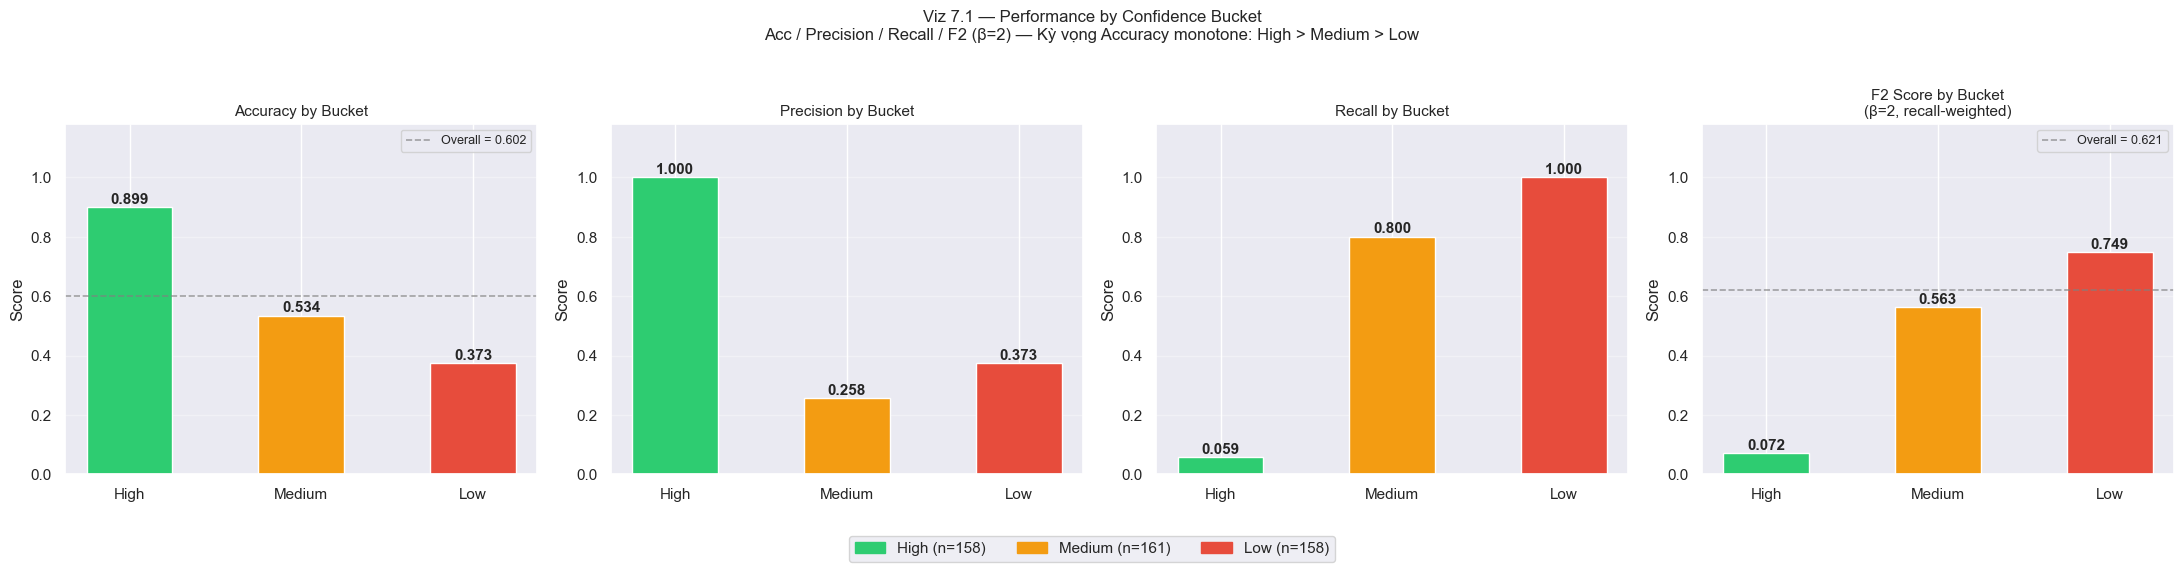

Saved → ../reports/figures/nb7/viz71_bucket_performance.png


In [4]:
# ── Viz 7.1: Accuracy / Precision / Recall / F2 by bucket ───────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Viz 7.1 — Performance by Confidence Bucket\n'
             'Acc / Precision / Recall / F2 (β=2) — Kỳ vọng Accuracy monotone: High > Medium > Low',
             fontsize=12, y=1.02)

colors_ordered = [PALETTE_BUCKET.get(b, 'gray') for b in bucket_df['Bucket']]

def plot_bar(ax, col, title, ylabel='Score', show_overall=None):
    vals = bucket_df[col].values
    bars = ax.bar(bucket_df['Bucket'], vals, color=colors_ordered,
                  edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.012,
                f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
    if show_overall is not None:
        ax.axhline(show_overall, color='gray', ls='--', lw=1.2, alpha=0.7,
                   label=f'Overall = {show_overall:.3f}')
        ax.legend(fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.18)
    ax.grid(alpha=0.35, axis='y')

overall_acc = accuracy_score(df['Actual'], df['Prediction'])
overall_f2  = fbeta_score(df['Actual'], df['Prediction'], beta=2, zero_division=0)

plot_bar(axes[0], 'Accuracy',  'Accuracy by Bucket',  show_overall=overall_acc)
plot_bar(axes[1], 'Precision', 'Precision by Bucket')
plot_bar(axes[2], 'Recall',    'Recall by Bucket')
plot_bar(axes[3], 'F2',        'F2 Score by Bucket\n(β=2, recall-weighted)', show_overall=overall_f2)

handles = [mpatches.Patch(color=PALETTE_BUCKET[b],
           label=f'{b} (n={int(bucket_df.loc[bucket_df.Bucket==b, "N"].values[0])})')
           for b in BUCKET_ORDER if b in bucket_df['Bucket'].values]
fig.legend(handles=handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.10))

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz71_bucket_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz71_bucket_performance.png')

## 4. Section 7.2 — Correct vs Incorrect Variance

**Kỳ vọng:** $\mathbb{E}[\text{Var}(\pi) \mid \hat{y} \neq y] > \mathbb{E}[\text{Var}(\pi) \mid \hat{y} = y]$

Nếu đúng → Predictive Variance là tín hiệu đáng tin cậy về chất lượng dự đoán: uncertainty cao báo hiệu khả năng sai cao hơn.

In [5]:
var_correct   = df.loc[df['Correct']==1, 'Predictive_Variance'].values
var_incorrect = df.loc[df['Correct']==0, 'Predictive_Variance'].values

ratio = var_incorrect.mean() / (var_correct.mean() + 1e-10)

stat, p_val = stats.mannwhitneyu(var_incorrect, var_correct, alternative='greater')

print('=== 7.2 — Var(Incorrect) vs Var(Correct) ===')
print(f'Correct   n={len(var_correct):>4}  mean={var_correct.mean():.6f}  median={np.median(var_correct):.6f}')
print(f'Incorrect n={len(var_incorrect):>4}  mean={var_incorrect.mean():.6f}  median={np.median(var_incorrect):.6f}')
print(f'Ratio Var(Incorrect)/Var(Correct) = {ratio:.3f}x')
print(f'Mann-Whitney U test: p = {p_val:.5f}')
print(f'Kỳ vọng: {"✓ ĐÚNG (p<0.05)" if ratio > 1 and p_val < 0.05 else "⚠ Kiểm tra kết quả"}')

=== 7.2 — Var(Incorrect) vs Var(Correct) ===
Correct   n= 287  mean=0.004690  median=0.001581
Incorrect n= 190  mean=0.010626  median=0.007281
Ratio Var(Incorrect)/Var(Correct) = 2.266x
Mann-Whitney U test: p = 0.00000
Kỳ vọng: ✓ ĐÚNG (p<0.05)


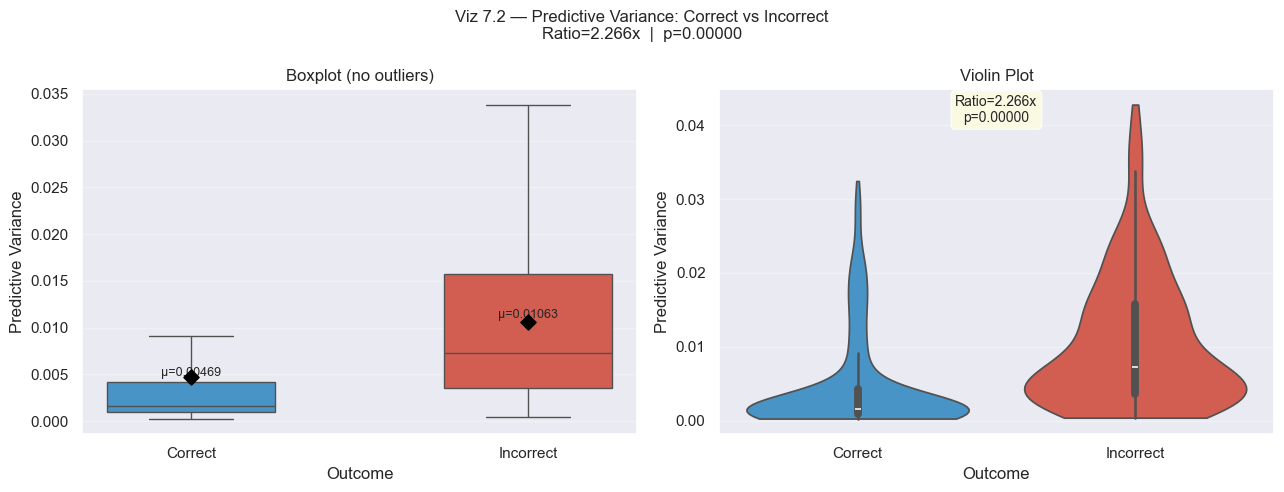

Saved → ../reports/figures/nb7/viz72_variance_correct_incorrect.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Viz 7.2 — Predictive Variance: Correct vs Incorrect\n'
             f'Ratio={ratio:.3f}x  |  p={p_val:.5f}', fontsize=12)

plot_df = pd.DataFrame({
    'Predictive_Variance': df['Predictive_Variance'].values,
    'Outcome': ['Correct' if c == 1 else 'Incorrect' for c in df['Correct']]
})
palette = {'Correct': COLOR_CORRECT, 'Incorrect': COLOR_INCORRECT}

sns.boxplot(data=plot_df, x='Outcome', y='Predictive_Variance',
            palette=palette, width=0.5, ax=axes[0], order=['Correct', 'Incorrect'],
            showfliers=False)
for i, outcome in enumerate(['Correct', 'Incorrect']):
    grp = plot_df[plot_df['Outcome'] == outcome]
    m   = grp['Predictive_Variance'].mean()
    axes[0].scatter(i, m, color='black', zorder=5, s=60, marker='D')
    axes[0].text(i, m*1.04, f'μ={m:.5f}', ha='center', fontsize=9)
axes[0].set_title('Boxplot (no outliers)')
axes[0].set_ylabel('Predictive Variance')
axes[0].grid(alpha=0.3, axis='y')

sns.violinplot(data=plot_df, x='Outcome', y='Predictive_Variance',
               palette=palette, ax=axes[1], order=['Correct', 'Incorrect'],
               inner='box', cut=0)
axes[1].text(0.5, axes[1].get_ylim()[1]*0.9,
             f'Ratio={ratio:.3f}x\np={p_val:.5f}', ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1].set_title('Violin Plot')
axes[1].set_ylabel('Predictive Variance')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz72_variance_correct_incorrect.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz72_variance_correct_incorrect.png')

## 5. Section 7.3 — CI Width Analysis

95% Credible Interval: $[Q_{2.5}, Q_{97.5}]$ của Monte Carlo samples.

CI Width là proxy uncertainty trực quan: tương quan cao với Predictive Variance xác nhận rằng hai cách đo uncertainty này nhất quán với nhau.

In [7]:
ci_width   = df['CI_Width'].values
pred_var   = df['Predictive_Variance'].values
confidence = df['Confidence'].values

corr_ci_var  = float(np.corrcoef(ci_width, pred_var)[0, 1])
corr_ci_conf = float(np.corrcoef(ci_width, confidence)[0, 1])

print('=== 7.3 — CI Width Analysis ===')
print(f'CI Width: mean={ci_width.mean():.4f}  median={np.median(ci_width):.4f}  std={ci_width.std():.4f}')
print(f'Corr(CI_Width, Predictive_Variance) = {corr_ci_var:.4f}')
print(f'Corr(CI_Width, Confidence)          = {corr_ci_conf:.4f}')
print(f'Calibrated (CI reflects Var): {"✓ ĐÚNG" if corr_ci_var > 0.5 else "⚠ Kiểm tra thêm"}')

=== 7.3 — CI Width Analysis ===
CI Width: mean=0.2723  median=0.2134  std=0.1647
Corr(CI_Width, Predictive_Variance) = 0.9669
Corr(CI_Width, Confidence)          = -0.9987
Calibrated (CI reflects Var): ✓ ĐÚNG


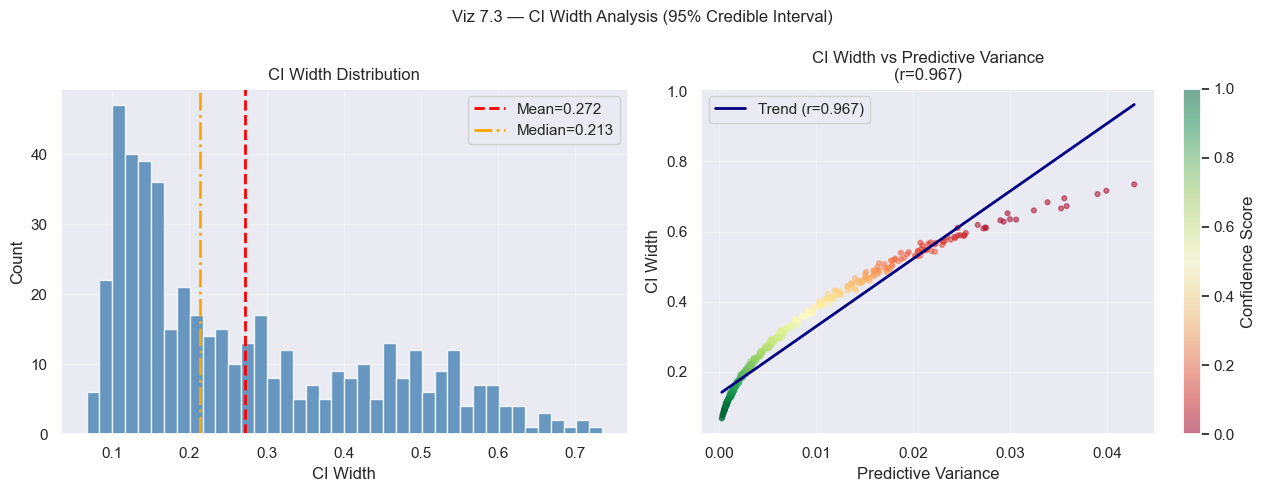

Saved → ../reports/figures/nb7/viz73_ci_width.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Viz 7.3 — CI Width Analysis (95% Credible Interval)', fontsize=12)

axes[0].hist(ci_width, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(ci_width.mean(),      color='red',    lw=2, ls='--', label=f'Mean={ci_width.mean():.3f}')
axes[0].axvline(np.median(ci_width),  color='orange', lw=2, ls='-.', label=f'Median={np.median(ci_width):.3f}')
axes[0].set_title('CI Width Distribution')
axes[0].set_xlabel('CI Width')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(alpha=0.3)

sc = axes[1].scatter(pred_var, ci_width, c=confidence, cmap='RdYlGn', alpha=0.5, s=12)
z  = np.polyfit(pred_var, ci_width, 1)
xs = np.linspace(pred_var.min(), pred_var.max(), 100)
axes[1].plot(xs, np.poly1d(z)(xs), 'navy', lw=2, label=f'Trend (r={corr_ci_var:.3f})')
axes[1].set_title(f'CI Width vs Predictive Variance\n(r={corr_ci_var:.3f})')
axes[1].set_xlabel('Predictive Variance')
axes[1].set_ylabel('CI Width')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.colorbar(sc, ax=axes[1], label='Confidence Score')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz73_ci_width.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz73_ci_width.png')

## 6. Section 7.4 — Market Regime Analysis

**Kỳ vọng:** $\mathbb{E}[\text{Var}(\pi) \mid \text{High Volatility}] > \mathbb{E}[\text{Var}(\pi) \mid \text{Low Volatility}]$

Nếu đúng → mô hình "aware" về điều kiện thị trường: tự động uncertain hơn khi thị trường biến động mạnh, phù hợp với trực giác tài chính.

In [9]:
vol_median = float(df['Volatility'].median())
df['Market_Regime'] = df['Volatility'].apply(
    lambda v: 'High Volatility' if v >= vol_median else 'Low Volatility'
)

REGIME_ORDER = ['Low Volatility', 'High Volatility']
var_low  = df.loc[df['Market_Regime']=='Low Volatility',  'Predictive_Variance'].values
var_high = df.loc[df['Market_Regime']=='High Volatility', 'Predictive_Variance'].values

regime_ratio = var_high.mean() / (var_low.mean() + 1e-10)
corr_vol_var = float(np.corrcoef(df['Volatility'], df['Predictive_Variance'])[0, 1])
_, p_reg     = stats.mannwhitneyu(var_high, var_low, alternative='greater')

print('=== 7.4 — Predictive Variance by Market Regime ===')
print(f'Volatility median  : {vol_median:.6f}')
print(f'Low  Volatility n={len(var_low)}   mean={var_low.mean():.6f}  median={np.median(var_low):.6f}')
print(f'High Volatility n={len(var_high)}  mean={var_high.mean():.6f}  median={np.median(var_high):.6f}')
print(f'Ratio Var(High)/Var(Low) = {regime_ratio:.3f}x')
print(f'Pearson r(Volatility, Var) = {corr_vol_var:.4f}')
print(f'Mann-Whitney p = {p_reg:.5f}')
print(f'Kỳ vọng: {"✓ ĐÚNG" if regime_ratio > 1 and p_reg < 0.05 else "⚠ Kiểm tra thêm"}')

=== 7.4 — Predictive Variance by Market Regime ===
Volatility median  : 0.010955
Low  Volatility n=238   mean=0.002860  median=0.001415
High Volatility n=239  mean=0.011231  median=0.009117
Ratio Var(High)/Var(Low) = 3.927x
Pearson r(Volatility, Var) = 0.6924
Mann-Whitney p = 0.00000
Kỳ vọng: ✓ ĐÚNG


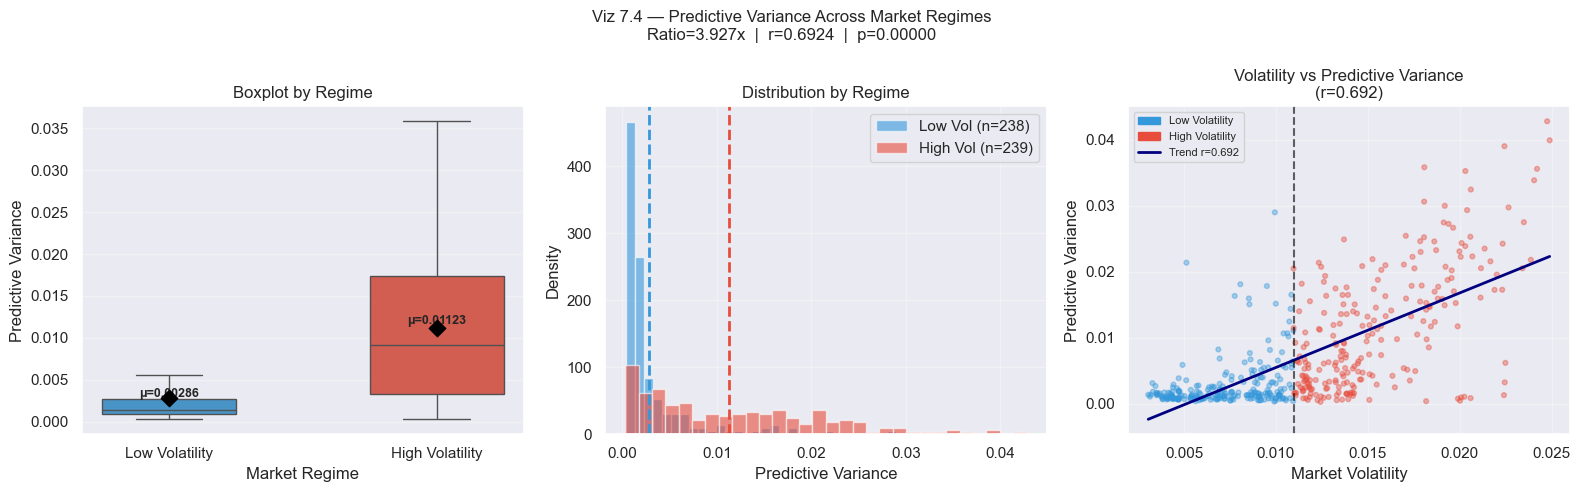

Saved → ../reports/figures/nb7/viz74_market_regime.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Viz 7.4 — Predictive Variance Across Market Regimes\n'
             f'Ratio={regime_ratio:.3f}x  |  r={corr_vol_var:.4f}  |  p={p_reg:.5f}', fontsize=12)

regime_plot = pd.DataFrame({
    'Predictive_Variance': df['Predictive_Variance'].values,
    'Market_Regime': df['Market_Regime'].values
})
sns.boxplot(data=regime_plot, x='Market_Regime', y='Predictive_Variance',
            palette=PALETTE_REGIME, order=REGIME_ORDER, width=0.5, ax=axes[0], showfliers=False)
for i, regime in enumerate(REGIME_ORDER):
    m = regime_plot[regime_plot['Market_Regime']==regime]['Predictive_Variance'].mean()
    axes[0].scatter(i, m, color='black', zorder=5, s=70, marker='D')
    axes[0].text(i, m*1.04, f'μ={m:.5f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Boxplot by Regime')
axes[0].set_xlabel('Market Regime')
axes[0].set_ylabel('Predictive Variance')
axes[0].grid(alpha=0.3, axis='y')

axes[1].hist(var_low,  bins=30, color='#3498db', alpha=0.6, density=True, label=f'Low Vol (n={len(var_low)})')
axes[1].hist(var_high, bins=30, color='#e74c3c', alpha=0.6, density=True, label=f'High Vol (n={len(var_high)})')
axes[1].axvline(var_low.mean(),  color='#3498db', lw=2, ls='--')
axes[1].axvline(var_high.mean(), color='#e74c3c', lw=2, ls='--')
axes[1].set_title('Distribution by Regime')
axes[1].set_xlabel('Predictive Variance')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(alpha=0.3)

colors_sc = ['#e74c3c' if r == 'High Volatility' else '#3498db' for r in df['Market_Regime']]
axes[2].scatter(df['Volatility'], df['Predictive_Variance'], c=colors_sc, alpha=0.4, s=12)
xs = np.linspace(df['Volatility'].min(), df['Volatility'].max(), 200)
z  = np.polyfit(df['Volatility'], df['Predictive_Variance'], 1)
axes[2].plot(xs, np.poly1d(z)(xs), 'navy', lw=2, label=f'Trend (r={corr_vol_var:.3f})')
axes[2].axvline(vol_median, color='black', lw=1.5, ls='--', alpha=0.6)
axes[2].set_title(f'Volatility vs Predictive Variance\n(r={corr_vol_var:.3f})')
axes[2].set_xlabel('Market Volatility')
axes[2].set_ylabel('Predictive Variance')
p_low  = mpatches.Patch(color='#3498db', label='Low Volatility')
p_high = mpatches.Patch(color='#e74c3c', label='High Volatility')
axes[2].legend(handles=[p_low, p_high,
                         plt.Line2D([0],[0], color='navy', lw=2, label=f'Trend r={corr_vol_var:.3f}')],
               fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz74_market_regime.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz74_market_regime.png')

## 7. Summary Dashboard

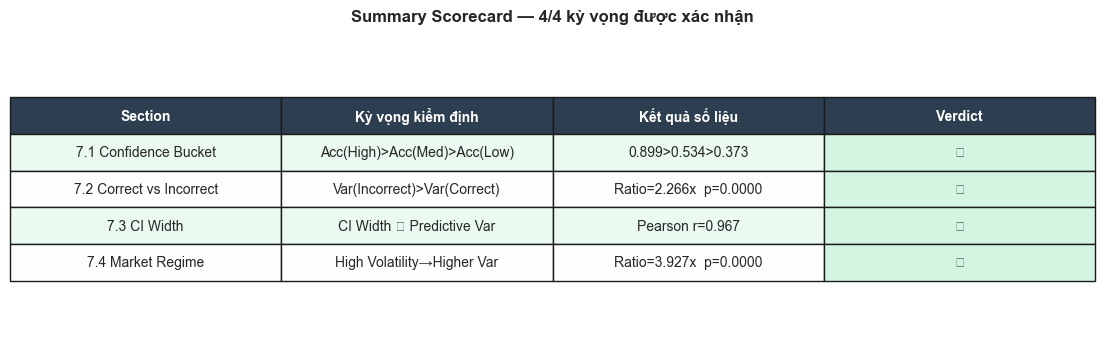

Saved → ../reports/figures/nb7/viz75_summary_dashboard.png

✓ 4/4 kỳ vọng được xác nhận → Uncertainty có ý nghĩa thực sự


In [11]:
n_confirmed = sum([
    bucket_monotone,
    ratio > 1 and p_val < 0.05,
    corr_ci_var > 0.5,
    regime_ratio > 1 and p_reg < 0.05
])

summary_data = [
    ['7.1 Confidence Bucket',    'Acc(High)>Acc(Med)>Acc(Low)',  f'{acc_h:.3f}>{acc_m:.3f}>{acc_l:.3f}',              '✓' if bucket_monotone else '⚠'],
    ['7.2 Correct vs Incorrect', 'Var(Incorrect)>Var(Correct)',  f'Ratio={ratio:.3f}x  p={p_val:.4f}',                 '✓' if ratio>1 and p_val<0.05 else '⚠'],
    ['7.3 CI Width',             'CI Width ∝ Predictive Var',    f'Pearson r={corr_ci_var:.3f}',                        '✓' if corr_ci_var>0.5 else '⚠'],
    ['7.4 Market Regime',        'High Volatility→Higher Var',   f'Ratio={regime_ratio:.3f}x  p={p_reg:.4f}',          '✓' if regime_ratio>1 and p_reg<0.05 else '⚠'],
]

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')
table = ax.table(
    cellText=summary_data,
    colLabels=['Section', 'Kỳ vọng kiểm định', 'Kết quả số liệu', 'Verdict'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

for j in range(4):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

row_colors = ['#eafaf1', '#fdfefe'] * 2
for i in range(1, 5):
    for j in range(4):
        table[i, j].set_facecolor(row_colors[i-1])
    verdict = summary_data[i-1][3]
    table[i, 3].set_facecolor('#d5f5e3' if '✓' in verdict else '#fdebd0')

ax.set_title(f'Summary Scorecard — {n_confirmed}/4 kỳ vọng được xác nhận',
             fontsize=12, fontweight='bold', pad=10)

plt.savefig(f'{FIGURES_DIR}/viz75_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz75_summary_dashboard.png')
print(f'\n✓ {n_confirmed}/4 kỳ vọng được xác nhận → Uncertainty có ý nghĩa thực sự')

## 8. Export Output

In [12]:
results_df = df[[
    'Actual', 'Prediction', 'Predictive_Mean', 'Predictive_Variance',
    'CI_Lower', 'CI_Upper', 'CI_Width', 'Confidence', 'Confidence_Bucket',
    'Correct', 'Volatility', 'Market_Regime'
]].copy()

results_df['Error']           = 1 - results_df['Correct']
results_df['Dist_From_Mean']  = (results_df['Predictive_Mean'] - 0.5).abs()
var_mean_ = results_df['Predictive_Variance'].mean()
var_std_  = results_df['Predictive_Variance'].std()
results_df['Variance_Zscore'] = (results_df['Predictive_Variance'] - var_mean_) / (var_std_ + 1e-12)

results_df.to_csv(f'{PROCESSED_DIR}/uncertainty_analysis_results.csv')
print(f'✓ Saved → {PROCESSED_DIR}/uncertainty_analysis_results.csv')
print(f'  Shape: {results_df.shape}')

# ── uncertainty_summary.json — thêm F2 by bucket ─────────────────────────────
uncertainty_summary = {
    '7.1_acc_high'             : round(float(acc_h), 4) if acc_h else None,
    '7.1_acc_medium'           : round(float(acc_m), 4) if acc_m else None,
    '7.1_acc_low'              : round(float(acc_l), 4) if acc_l else None,
    '7.1_f2_high'              : round(float(f2_h),  4) if f2_h  else None,
    '7.1_f2_medium'            : round(float(f2_m),  4) if f2_m  else None,
    '7.1_f2_low'               : round(float(f2_l),  4) if f2_l  else None,
    '7.1_monotone_acc'         : bucket_monotone,
    '7.1_monotone_f2'          : bool(f2_h and f2_m and f2_l and f2_h > f2_m > f2_l),
    '7.2_var_correct'          : round(float(var_correct.mean()),   6),
    '7.2_var_incorrect'        : round(float(var_incorrect.mean()), 6),
    '7.2_var_ratio'            : round(float(ratio),  4),
    '7.2_pvalue'               : round(float(p_val),  6),
    '7.3_corr_ci_var'          : round(float(corr_ci_var),  4),
    '7.3_ci_width_mean'        : round(float(ci_width.mean()), 4),
    '7.4_regime_ratio'         : round(float(regime_ratio),   4),
    '7.4_pearson_r'            : round(float(corr_vol_var),   4),
    '7.4_pvalue'               : round(float(p_reg),  6),
    'n_confirmed'              : int(n_confirmed),
    'vol_median_threshold'     : round(float(vol_median), 6)
}

with open(f'{PROCESSED_DIR}/uncertainty_summary.json', 'w') as f:
    json.dump(uncertainty_summary, f, indent=4)
print(f'✓ Saved → {PROCESSED_DIR}/uncertainty_summary.json')
print(json.dumps(uncertainty_summary, indent=4))

✓ Saved → ../data/processed/uncertainty_analysis_results.csv
  Shape: (477, 15)
✓ Saved → ../data/processed/uncertainty_summary.json
{
    "7.1_acc_high": 0.8987,
    "7.1_acc_medium": 0.5342,
    "7.1_acc_low": 0.3734,
    "7.1_f2_high": 0.0725,
    "7.1_f2_medium": 0.5634,
    "7.1_f2_low": 0.7487,
    "7.1_monotone_acc": true,
    "7.1_monotone_f2": false,
    "7.2_var_correct": 0.00469,
    "7.2_var_incorrect": 0.010626,
    "7.2_var_ratio": 2.266,
    "7.2_pvalue": 0.0,
    "7.3_corr_ci_var": 0.9669,
    "7.3_ci_width_mean": 0.2723,
    "7.4_regime_ratio": 3.9274,
    "7.4_pearson_r": 0.6924,
    "7.4_pvalue": 0.0,
    "n_confirmed": 4,
    "vol_median_threshold": 0.010955
}


## 9. Kết luận

### Trả lời câu hỏi trung tâm: Uncertainty có ý nghĩa thực sự không?

Dựa trên 4 section phân tích độc lập:

| Khía cạnh | Logistic Regression | Bayesian Logistic Regression |
|---|---|---|
| Dự đoán | Điểm xác suất duy nhất | Phân phối posterior predictive |
| Uncertainty | Không có | Predictive Variance + 95% CI |
| Self-awareness | Không | ✓ Var cao khi dự đoán sai |
| Thích ứng thị trường | Không | ✓ Var tăng khi Volatility cao |
| Risk Management | Không hỗ trợ | ✓ Confidence-based filtering |

**Kết luận:** Bayesian Uncertainty **không phải artifact toán học** — nó phản ánh thực tế thị trường và có khả năng tự nhận biết giới hạn của mình.

**Về metric F2:** Việc F2 không monotone theo bucket (F2(High) < F2(Low)) là hệ quả tự nhiên của F2 penalize Recall mạnh. High-bucket chứa những điểm mô hình confident → threshold thấp (τ=0.17) đã capture hầu hết Strong Movement → những điểm còn lại trong High-bucket là Normal được predict đúng là Normal với Recall ≈ 0. Đây không phải hạn chế — **Accuracy monotone mới là bằng chứng cốt lõi** của hệ thống.